Author(s): @jihoonkim2100 kimj@cbs.mpg.de | Clara Weber webercl@cbs.mpg.de

Last updated: 19-05-2026

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

|Magic Command|Description|
|:-|:-|
|`%matplotlib inline`|Renders plots natively within the notebook output directly below the code cell.|
|`%load_ext autoreload %autoreload 2` | Automatically reloads imported Python modules before executing code. This ensures that any changes made to external scripts are instantly reflected in the notebook without needing to restart the kernel.|

[TODO] Short description of notebook

# Introduction to Neuroimaging coding

In this notebook, we aim to provide a walk-throug, interactive resource to introduce you to the neuroimaging tools that we (CNG lab) commonly use.

## Getting started - or 'Housekeeping'

Import the library<br>
`[TODO] add explanation of library from, import, as meaning`

In [2]:
from brainspace.datasets import (
    load_conte69,
    load_parcellation,
    load_group_fc
)
from brainspace.gradient import compute_affinity, GradientMaps
from brainspace.mesh.mesh_creation import build_polydata
from brainspace.plotting import plot_hemispheres
from brainspace.utils.parcellation import reduce_by_labels, map_to_labels
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn.plotting import plot_matrix
import numpy as np
import pandas as pd
from pyvirtualdisplay import Display
import session_info

# Set the seed
np.random.seed(42)

pydisplay = Display(visible=0, size=(800, 200))
pydisplay.start()

# Print the detailed report
session_info.show()

## Very basic python intro

Please use the following lines to familiarize yourself with some basics. You are very encouraged to play around a bit, create a new cell and try something new!

In [3]:
# everything behind a hashtag is a comment and will not be compiled
# This is a comment, and i can write everything I want here :)
# Flooble glooble

First, we want to define a variable. A variable is like an envelope in which you can store all kinds of things, e.g. numbers (integers, floats) or words (strings). You can show print them using `print()`

In [4]:
# Define a variable
var = 8
another_var = 'rabbit'

# show content of variable
print(var, another_var)

8 rabbit


`print()` is a function. You can recognize functions as they have parentheses after them. You can also define your own functions. They need input arguments (in the parentheses in the definition) and return the value calculated in the function.

In [5]:
def my_own_function(in_number):
    """
    in these docstrings you explain what the function does, and specify input and output
    Adds 3 to input number

    Input: a float
    Returns: that float + 3
    """
    out_number = in_number + 3
    return out_number

In [6]:
my_own_function(var)

11

--> what would happen if you ran my_own_function() with other inputs? try it out!

In [7]:
# here you can code yourself:

Next, let's look at loops. Imagine you have three prices that are all increased by 20%, but you do not want to calculate all prices separately. Instead, you can do the following:

In [8]:
prices = [3.45, 6.99, 7.49] # this is a list

for p in prices: # this iterates through the list, with every single entry in the list becoming p in an interation
    new_price = p * 1.2
    print(f'{p} now costs {new_price}')

3.45 now costs 4.14
6.99 now costs 8.388
7.49 now costs 8.988


Another important functionality is if-statements. They test whether a condition is true or false, and do different things depending on this condition. Let's try it out by testing whether it is a workday or not.

In [9]:
today = 'friday'

# specify workdays
workdays = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday']
weekend = ['saturday', 'sunday']

# now test whether the value of today is part of one of the lists
if today in workdays:
    print('Today is a workday.')
elif today in weekend: # with elif (else/if, i set another condition that can be true or false)
    print('Today is not a workday! Happy weekend.')
else: # here we specify what happens when if (and elif) are False
    print('Input not recognized')

Today is a workday.


To understand how if statements work, it is helpful to familiarize yourself with booleans. Booleans are datatypes just like floats (numbers) or strings (words), but they can be either `True` or `False` (always with capitalized first letter). This is still shown a bit later in the tutorial when we introduce the mask.

For most data handling in neuroimaging, we need arrays. In python, the numpy library (usually imported as np) can be used to handle arrays/matrices. To use the functions in numpy, we first need to install it (you only need to do this once), and then import it into your script.

In [10]:
# import numpy functions
import numpy as np

Now we can use numpy functions by calling them with `np.function()`. This is the benefit of specifying a name for the packages you import: Several packages have functions with the same name, for examble nibabel and numpy both have the funciton `load()` but it does different things. If we would just `import numpy` and `import nibabel`, we couldn't differentiate which `load()` we call, but if we `import numpy as np` and `import nibabel as nib` we can call `np.load()` and `nib.load()` separately depending on what we need.

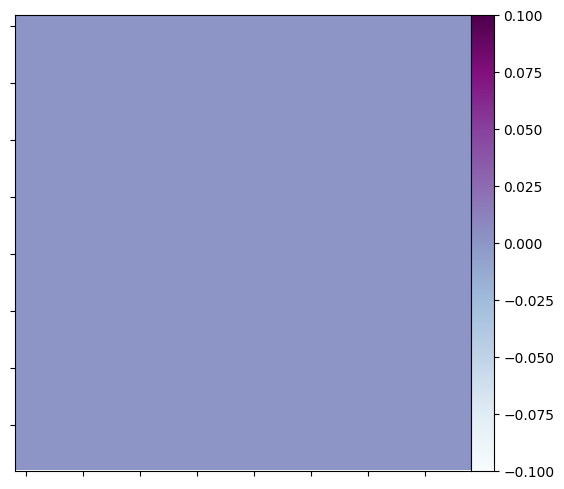

In [11]:
# create an array of a certain size
example_array = np.zeros((20,20))

plot_matrix(example_array, cmap = 'BuPu')

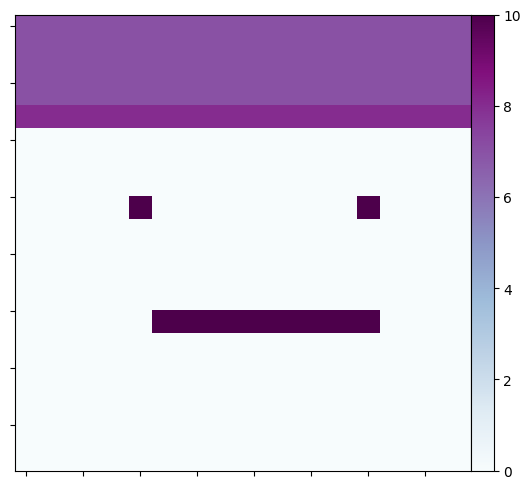

In [12]:
# access certain values within an array
example_array[8,5] = 10 # here i set the value in the 8th row 5th column to 10
example_array[8,15] = 10 # here i set the value in the 8th row 15th column to 10

# you can also select whole columns or rows
example_array[4,:] = 8 # here i select all values (:) in the 4th row and set it to 7

# with colons : i can specify ranges
example_array[:4,:] = 7 # here i select all between 0th and 3rd row (: = from beginning to value or from value to end) and set it to 5
example_array[13,6:16] = 10 # here i select all values in the 15th row between the 6th and 16th column

# now let's look at the new matrix
plot_matrix(example_array, cmap = 'BuPu')

In [13]:
# you can show the size of an array like this
print(example_array.shape)

(20, 20)


In [14]:
# sometimes you also need to know how many different values there are in your matrix
print(np.unique(example_array)) # here we expect the values 0, 5, 7, 10 based on how we defined the array

[ 0.  7.  8. 10.]


### Coding exercise

try to give the matrix a nose!

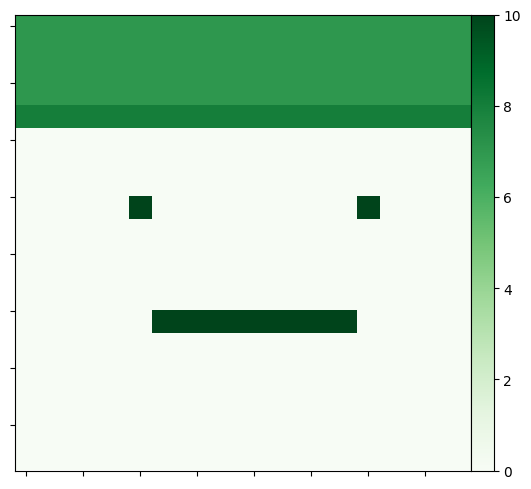

In [15]:
exercise_array = np.zeros((20,20))

# this is from the previous code
exercise_array[8,5] = 10
exercise_array[8,15] = 10
exercise_array[4,:] = 8
exercise_array[:4,:] = 7
exercise_array[13,6:15] = 10

# add nose here!!



# plot
plot_matrix(exercise_array, cmap = 'Greens')

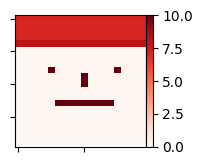

In [16]:
# --- SOLUTION: Click blue bar on the left to expand code ---

# title Solution

exercise_array[9:11,10] = 10

# plot
fig, ax = plt.subplots(figsize=(2,2)) # this is just to show it a little smaller

plot_matrix(exercise_array, cmap = 'Reds', figure = fig)

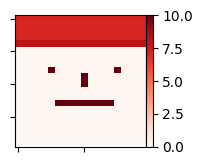

In [17]:
#@title Solution

exercise_array[9:11,10] = 10

# plot
fig, ax = plt.subplots(figsize=(2,2)) # this is just to show it a little smaller

plot_matrix(exercise_array, cmap = 'Reds', figure = fig)

## Brain visualization functions

Here, i use brainspace to show you how data visualization works. You can also use other tools such as the ENIGMA toolbox. Pick your poison :) Here is the official documentation for brainspace https://brainspace.readthedocs.io/en/latest/

In [18]:
# load surface, here we use conte69 - alternatively, use fsa5
surf_lh, surf_rh = load_conte69()

Conte69 has 64984 surface points. The first 32492 correspond to the left hemisphere, the last 32492 to the right hemisphere. Conte69 is symmetric, FSA5 is not. Let's create nonsense data in this format and project onto the surface.

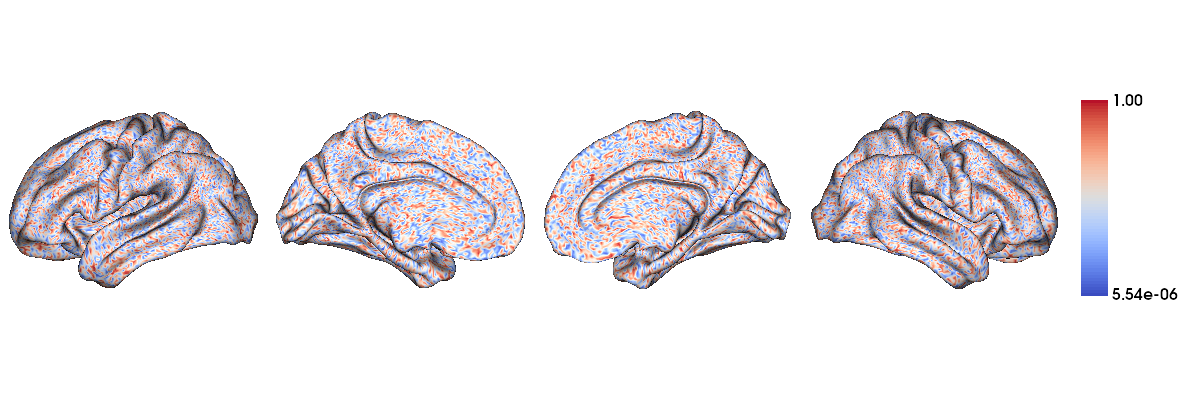

In [19]:
nonsense_data = np.random.rand(64984)

plot_hemispheres(surf_lh, surf_rh, nonsense_data, # first use the surfaces you want to use and your data
                 embed_nb = True, interactive = False, # this is to make plots work in notebook
                 size = (1200,400), zoom = 1.2, # set size of display
                 color_bar = True, cmap = 'coolwarm') # show color bar and set color map

### Parcellations and midline mask

Sometimes, we want to show all data points on the cortex. But sometimes, it can be very computationally expensive to work with 70k data points. So we can also use parcellations, where cortical regions are grouped into parcels. Let's look at a common parcellation, the Schaefer 400 parcellation

In [22]:
# we will load a parcellation
s400 = load_parcellation('schaefer', 400, join = True)

In [23]:
# what does the parcellation look like?
print(np.unique(s400).shape, 'unique values \nshape of s400 is', len(s400))

(401,) unique values 
shape of s400 is 64984


As you can see, we loaded a vector that has as many entries as our surface has vertices. Every entry is a number that corresponds to one of the 400 parcels. Now look at what this parcellation looks like on the cortical surface:

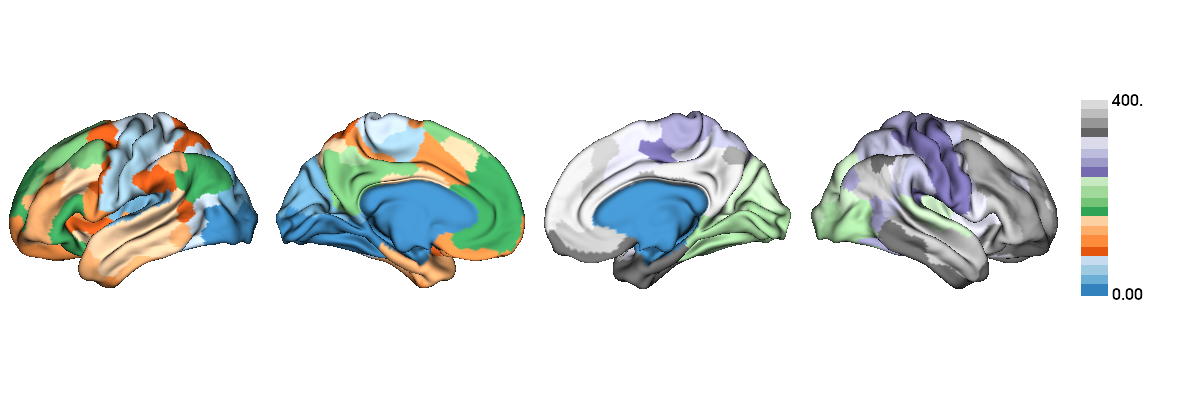

In [24]:
plot_hemispheres(surf_lh, surf_rh, s400,
                 embed_nb = True, interactive = False,
                 size = (1200,400), zoom = 1.2,
                 color_bar = True, cmap = 'tab20c')

Now, we want to parcellate our data, so we want to summarize all the values in each parcel to one value. Usually, we take the mean. So let's compress our 64984 data points to 400 parcels.

In [25]:
data_400 = reduce_by_labels(nonsense_data, s400)

print(data_400.shape) # there will be one added value as it is 400 parcels (1-400) + 0 for midline

(401,)


Now we want to plot parcellated data. To plot it, we need 64984 data points again. To reproject this to the surface, we use a mapping tool.

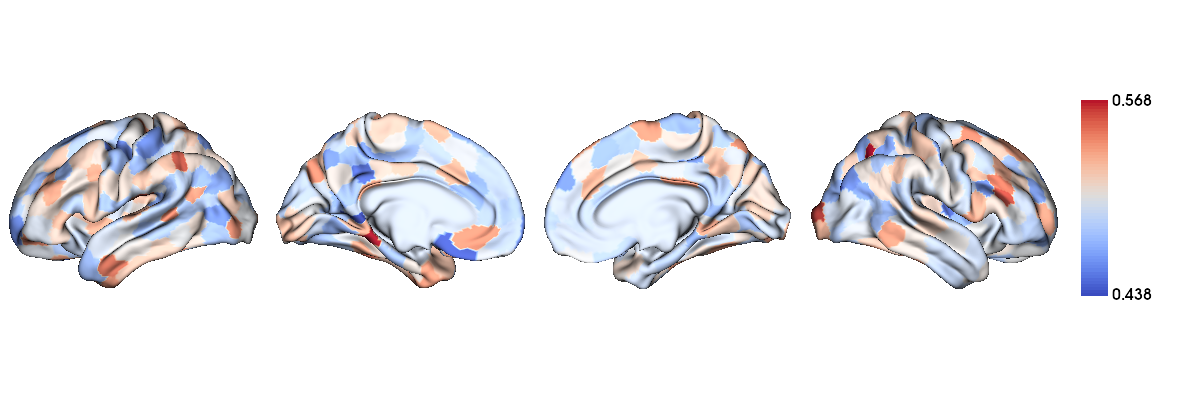

In [ ]:
data_400_mapped_to_surface = map_to_labels(data_400, s400)

plot_hemispheres(surf_lh, surf_rh, data_400_mapped_to_surface,
                 embed_nb = True, interactive = False,
                 size = (1200,400), zoom = 1.2,
                 color_bar = True, cmap = 'coolwarm')

You can see that data is now grouped into parcels. Also, above in the parcellation you can see that the medial wall (where both hemispheres connect and we do not expect useful data) is parcel number 0. We can use this to 'hide' the medial wall, i.e. replace the values there with nan (non-available) / Even when we use vertex-wise data.

In [27]:
mask = s400 == 0 # this defines a mask that can be used to select every location where values in s400 are 0

Double == means: we compare two values and get an output of True or False. These are called Booleans. A single = means: we define a new variable. I will introduce comparators in the following, then we will return to the mask.

In [28]:
example_var = 8 # here, single = means we define something
print('Is your variable equal to seven?', example_var == 7) # test ==

# this works similar for !=, >, <
print('Is your variable not equal to seven?', example_var != 7) # test != (is not equal to)
print('Is your variable larger than seven?', example_var > 7) # test > (is larger than)
print('Is your variable smaller than seven?', example_var < 7) # test < (is smaller than)

Is your variable equal to seven? False
Is your variable not equal to seven? True
Is your variable larger than seven? True
Is your variable smaller than seven? False


Now, back to the mask. Here, we applied == to a whole vector. Let's look at the output

In [29]:
mask

array([False, False, False, ..., False, False, False])

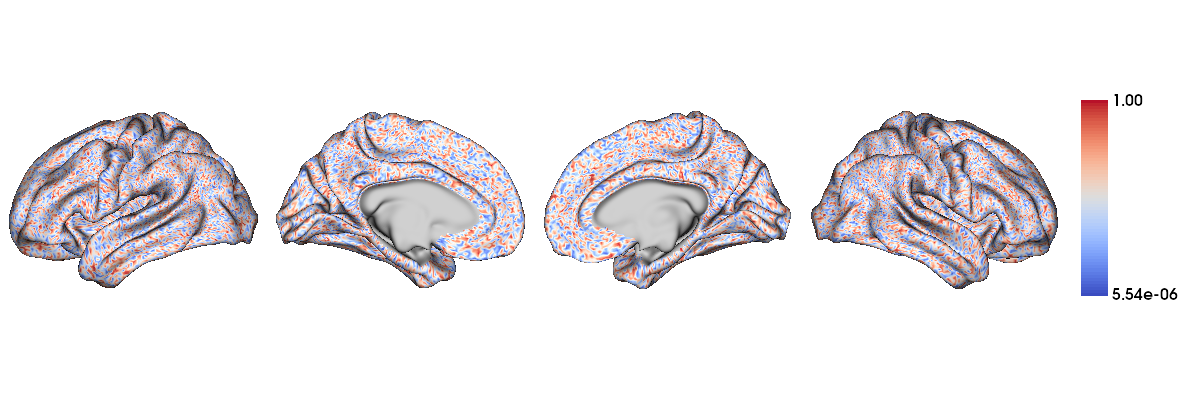

In [30]:
# Now we can select all values where mask == True from our random numbers vector
nonsense_data[mask] = np.nan # make mask values nan

plot_hemispheres(surf_lh, surf_rh, nonsense_data,
                 embed_nb = True, interactive = False,
                 size = (1200,400), zoom = 1.2,
                 color_bar = True, cmap = 'coolwarm',
                 nan_color = (.7,.7,.7,1)) # set color value for nan values = the selected RGB values here correspond to grey

There is a lot of different parcellations out there. I only intruced Schaefer here as it is a commonly used and maybe most useful one. If you want to use any other parcellation, the same system applies - you just need a vector that specifies the parcels.

### Coding exercises

If you want, you can test your knowledge now.<br>
Here is an exercise:<br>
Create an array that can be plotted onto the surface, where all values are 0.<br>
Then, set all values in the left hemisphere to 1.<br>

In [ ]:
# code here

your_array = ....

In [ ]:
# plot intermediate outcome here
plot_hemispheres(surf_lh, surf_rh, your_array,
                 embed_nb=True, interactive = False,
                 size = (1200,400), zoom = 1.2,
                 color_bar = True, cmap = 'coolwarm',
                 nan_color = (.7,.7,.7.1))

Good job so far! Second exercise: We previously used the Schaefer parcellation to create a midline mask - now, i want you to hide all parcels except number 260.

In [ ]:
# code here

your_array_masked = ....

In [ ]:
# plot your array
plot_hemispheres(surf_lh, surf_rh, your_array_masked,
                 embed_nb=True, interactive = False,
                 size = (1200,400), zoom = 1.2,
                 color_bar = True, cmap = 'coolwarm',
                 nan_color = (.7,.7,.7.1))

Good job!<br>
Below are the solutions. Please try to solve the problems yourself - Coding is all about problem solving, so don't be discouraged and just try it out. The more mistakes you make, the more you learn :)

### Solution

In [ ]:
#@title Solution

# define array
exercise2_data = np.zeros(64984)

# make left hemisphere 1
exercise2_data[:32492] = 1
exercise2_data[mask] = np.nan

# plot intermediate
plot_hemispheres(surf_lh, surf_rh, exercise2_data,
                 embed_nb=True, interactive = False,
                 size = (600,200), zoom = 1,
                 color_bar = True, cmap = 'coolwarm',
                 nan_color = (.7,.7,.7,1))

### Solution part 2

In [ ]:
#@title Solution part 2

# now mask schaefer parcel 260
mask_s20 = s400 != 260

exercise2_data_masked = exercise2_data.copy()

exercise2_data_masked[mask_s20] = np.nan

# plot
plot_hemispheres(surf_lh, surf_rh, exercise2_data_masked,
                 embed_nb=True, interactive = False,
                 size = (600,200), zoom = 1,
                 color_bar = True, cmap = 'coolwarm',
                 nan_color = (.7,.7,.7,1))

## HCP connectivity data

Here, we use functional connectivity data from the human connectome project (HCP), available via brainspace. See how to load individual data below.

In [31]:
fc_matrix = load_group_fc(parcellation = 'schaefer', scale = 400) # this is already preprocessed and everything. Usually we need to do this before, but here you don"t have to worry about ir for once

This gives us a 400 x 400 matrix. Let's visualize this real quick.

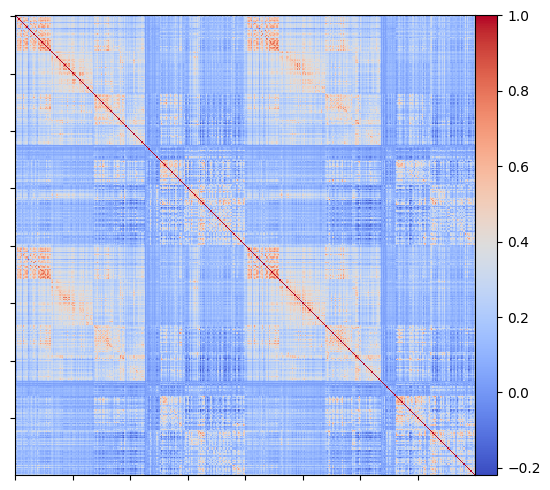

In [32]:
plot_matrix(fc_matrix, cmap = 'coolwarm')

Now, if we want to plot it onto the surface, we need a 64984, vector again. We already know how to bring parcellated data in 400, shape to a 64984, shape, (see map_to_labels() above). But now, we have a 400,400 (two-dimensional) data - so first, we need to bring it into one dimension. We can do this for example by creating the average, using np.mean. If you use np.mean, it gives you the overall average (so just one number), but you can specify axis so it creates the row-wise or column-wise average.

In [33]:
# this is what happens if we just use np.mean

print(np.mean(fc_matrix)) # we expect only one value but we need the mean for each row/column

0.2088529968891225


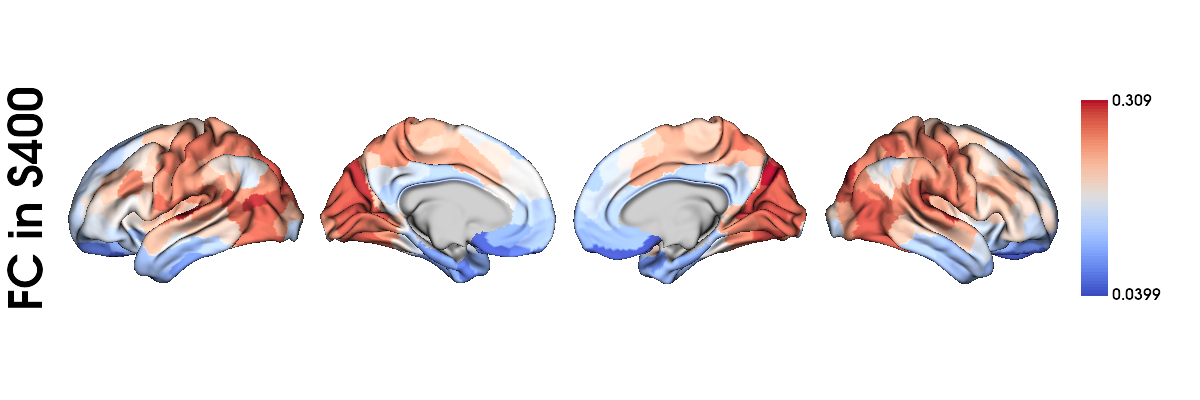

In [34]:
# now create row wise average
avg_fc_s400 = np.mean(fc_matrix, axis = 0)
# add one entry at beginning for midline
avg_fc_s400 = np.insert(avg_fc_s400, 0, 0)

# and map to labels
avg_fc = map_to_labels(avg_fc_s400, s400)

# apply midline mask
avg_fc[mask] = np.nan

# then plot
plot_hemispheres(surf_lh, surf_rh, avg_fc,
                 embed_nb = True, interactive = False,
                 size = (1200,400), zoom = 1.2,
                 color_bar = True, cmap = 'coolwarm',
                 label_text = ['FC in S400'],
                 nan_color = (.7,.7,.7,1))

### Gradients

We just projected data onto the surface. First, we reduced its dimensionality to one dimension, then we were able to plot it. Another way to reduce the dimensionality of data and find trajectories of organization is gradient decomposition.

https://brainspace.readthedocs.io/en/latest/python_doc/auto_examples/plot_tutorial1.html#sphx-glr-python-doc-auto-examples-plot-tutorial1-py

Gradient decomposition uses/is dimensionality reduction. This means that data from multiple dimensions (matrix, two dimensions) is reduced to one (vector, one dimension).
The concept is a little tricky, I usually explain it like this: Imaging you have a data cloud (see below in black) and its shape is difficult to describe. What you can do is shine a light from a certain angle and project it onto a plane. This way, we can see structures in the data that are easier to understand. Depending on the angle of the light, we get different shapes. These would refer to components and we can rank them by how closely they resemble the original shape (= how much variance they explain in the original data).

#### For visualization only

In [ ]:
#@title For visualization only
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

radius = 1.0
height = 3.0
n_surface = 250   # points on curved surface
n_face = 200      # points per circular face
rng = np.random.default_rng(42)

theta = rng.uniform(0, 2 * np.pi, n_surface)
z_surf = rng.uniform(0, height, n_surface)
x_surf = radius * np.cos(theta)
y_surf = radius * np.sin(theta)

r_face = np.sqrt(rng.uniform(0, radius**2, n_face))  # uniform disk sampling
theta_face = rng.uniform(0, 2 * np.pi, n_face)
x_face = r_face * np.cos(theta_face)
y_face = r_face * np.sin(theta_face)
z_bottom = np.zeros(n_face)
z_top = np.full(n_face, height)

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection="3d")
ax.set_box_aspect([1, 1, 1.5])

ax.scatter(x_surf, y_surf, z_surf,   s=2, alpha=0.4, color="black")
ax.scatter(x_face, y_face, z_bottom, s=2, alpha=0.4, color="black")
ax.scatter(x_face, y_face, z_top,    s=2, alpha=0.4, color="black")

proj_z   = -1.8   # XY plane (floor) — circular projection of the faces
proj_y   =  1.6   # XZ plane (back wall) — rectangular side projection
proj_x   = -1.6   # YZ plane (side wall) — rectangular side projection

# 1. Onto XY plane (z = proj_z)  → shows circle / disk
ax.scatter(x_face, y_face, proj_z,  s=4, alpha=1, color="red")

# 2. Onto XZ plane (y = proj_y)  → shows rectangle
ax.scatter(x_surf,  proj_y, z_surf, s=4, alpha=1, color="blue")

plt.tight_layout()
plt.show()

In neuroimaging, this give us gradients/components that tell us which areas in the brain are more similar and which are more different from one another. This way, we can describe the brain not only by pre-defining hierarchies and brain areas of interest, but by its intrinsic properties.

The idea of gradients was first introduced based on FC matrices, although we can use it on all kinds of matrices. Let's take the FC matrix and make a gradient out of it.

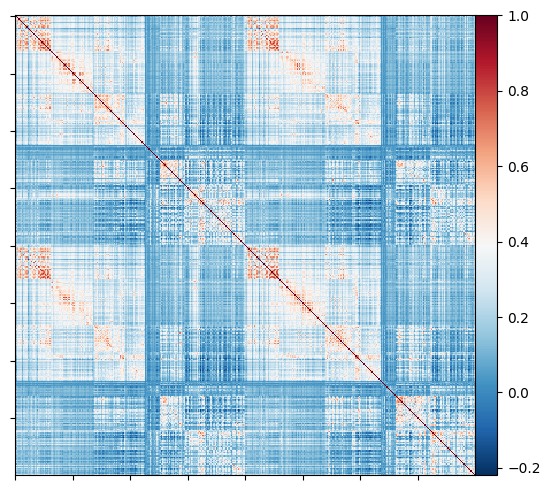

In [35]:
fc_matrix = load_group_fc(parcellation = 'schaefer', scale = 400) # should already be loaded but let's get it again
plot_matrix(fc_matrix)

Above shows what the original 2d matrix looks like. Brainspace gradient decomposition now creates a scarcity matrix at 10% highest connectivity and creates an affinity map (usually with normalized angle proximity, but some also use cosine). I won't explain this here in detail, see Brainspace for reference :)

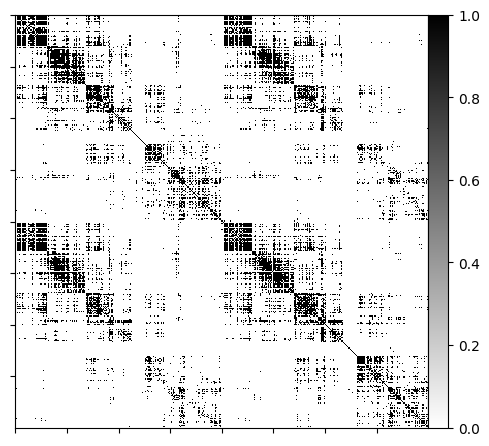

In [36]:
plot_matrix(fc_matrix>np.percentile(fc_matrix, 90), figure=(5,5), colorbar=True, cmap='binary')

Above is scarcity matrix, let's get affinity matrix now:

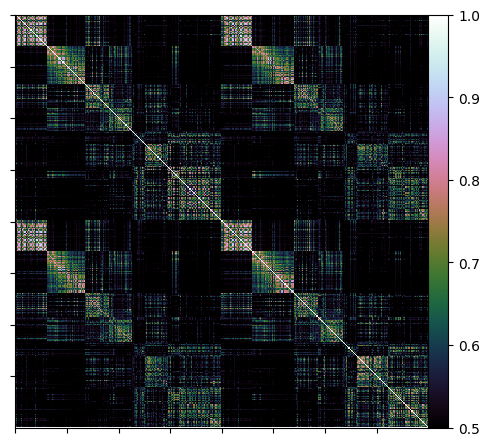

In [37]:
affinity_matrix = compute_affinity(fc_matrix, kernel = 'normalized_angle')
plot_matrix(affinity_matrix, figure=(5,5), colorbar=True, cmap='cubehelix')

Now we can feed this matrix into dimensionality reduction. The Brainspace toolbox offers three different algorithms for this step: PCA (principal component analysis), LE (Laplacian Eigenmaps), DM (Diffusion embedding). PCA is linear and DM is nonlinear (oversimplified). Usually the correlation between PCA and DM gradients will be very very high (r>0.95). I here demonstrate DM.

In [38]:
gm = GradientMaps(n_components=10, random_state=10)
gm.fit(fc_matrix)

print(gm.gradients_.shape)

(400, 10)


We created 10 gradients here. The output is one dimension "smaller" than the input (2d --> 1d). So now we get a 400, length vector (for 10 gradients) that we can visualize on the surface:

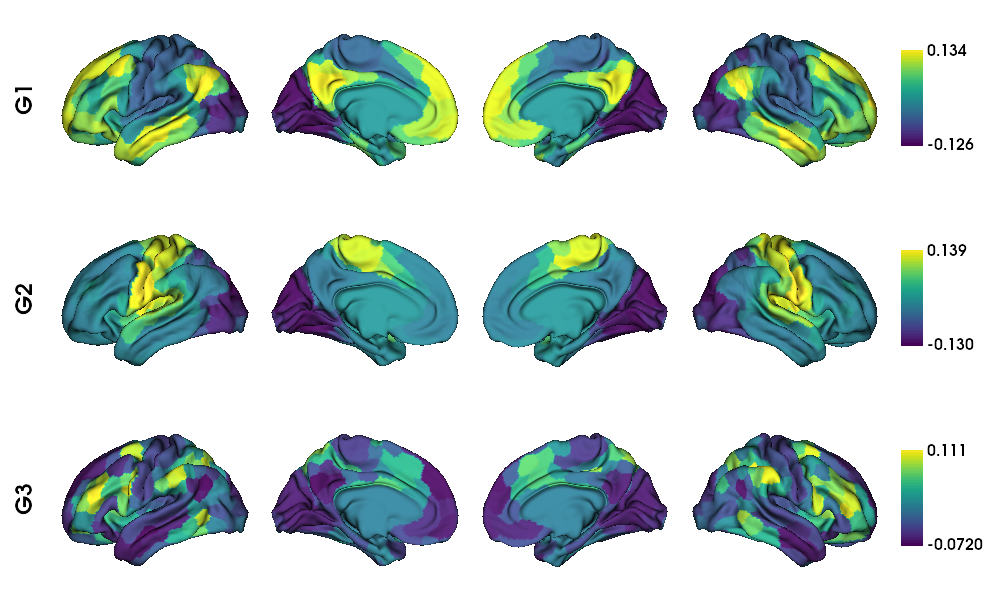

In [39]:
surface_gradients = [map_to_labels(np.insert(gm.gradients_[:, i], 0, 0), s400) for i in range(3)]
plot_hemispheres(surf_lh, surf_rh, surface_gradients,
                 embed_nb = True, interactive = False,
                 size = (1000,600), zoom = 1.2,
                 color_bar = True, cmap = 'viridis',
                 label_text = ['G1', 'G2', 'G3'],
                 nan_color = (.7,.7,.7,1))

This is the typical distribution of gradients: The primary gradient runs from sensorimotor and visual regions to transmodal regions (temporoparietal junction, prefrontal cortex, precuneus) that are involved in "higher order cognition", such as self-generated thought. The second gradient differentiates sensorimotor and visual areas.
The colors here represent arbitrary units. It only tells us that yellow areas are more similar and different from purple areas, but they do not represent a biological value.